In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [50]:
# 1. Lade den Datensatz
file_path = "synthetic_survey_data_NoNaNs_100.csv"  # Pfad ggf. anpassen
df = pd.read_csv(file_path)
df

,Q1,Q2A,Q2B,Q2C,Q2D,Q2E,Q2F,Q2G,Q4A,Q4B,...,Q12I,Q13,Q14,Q15,Q16,Q17A,Q17B,Q17C,Q17D,Q17E
0,5.0,2.0,2.0,2.0,2.0,1.0,3.0,1.0,2.0,3.0,...,2.0,1.0,11.0,4.0,1.0,1.0,0.0,1.0,0.0,0.0
1,4.0,2.0,2.0,2.0,1.0,3.0,3.0,3.0,2.0,3.0,...,4.0,2.0,8.0,3.0,3.0,1.0,0.0,0.0,1.0,0.0
2,3.0,1.0,1.0,2.0,2.0,3.0,3.0,1.0,3.0,2.0,...,3.0,2.0,8.0,15.0,2.0,1.0,0.0,1.0,0.0,1.0
3,5.0,3.0,2.0,1.0,1.0,1.0,1.0,1.0,2.0,3.0,...,2.0,1.0,11.0,5.0,1.0,1.0,0.0,1.0,1.0,1.0
4,2.0,2.0,2.0,2.0,2.0,3.0,2.0,3.0,1.0,2.0,...,3.0,2.0,12.0,1.0,2.0,0.0,1.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,1.0,3.0,3.0,2.0,2.0,3.0,3.0,2.0,2.0,2.0,...,3.0,2.0,11.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0
496,5.0,3.0,1.0,2.0,2.0,3.0,2.0,3.0,2.0,3.0,...,2.0,2.0,7.0,17.0,1.0,1.0,0.0,1.0,0.0,0.0
497,2.0,3.0,2.0,1.0,1.0,2.0,3.0,2.0,2.0,2.0,...,1.0,1.0,3.0,2.0,1.0,0.0,0.0,0.0,1.0,0.0
498,4.0,2.0,2.0,1.0,2.0,3.0,2.0,3.0,2.0,2.0,...,3.0,1.0,13.0,4.0,2.0,0.0,0.0,0.0,1.0,0.0


In [51]:
# 2. Liste der Genussvariablen laut Vorgabe
genuss_variablen = [
    "Q2C", "Q2D", "Q6C", "Q7A", "Q7C", "Q8A", "Q8B", "Q8C", "Q8E", "Q8G", "Q8J",
    "Q9A", "Q9B", "Q9C", "Q9D", "Q9E", "Q9F", "Q9G", "Q9H", "Q9I", "Q9J", "Q9K", "Q9L",
    "Q10A", "Q11A", "Q11B", "Q11C", "Q11D", "Q11E", "Q11F", "Q11G", "Q11H", "Q11I",
    "Q12G"
]

In [52]:
# 3. Filtere den Datensatz auf die Genussvariablen
df_genuss = df[genuss_variablen]

In [53]:
# 4. Berechne den Mittelwert jeder Variable (Sensorprofil)
means = df_genuss.mean().round(2).sort_values(ascending=False)

In [54]:
# 5. Erstelle Radar Chart (Sensorbild)
labels = means.index.tolist()
values = means.values.tolist()

In [55]:
# Wiederhole den ersten Wert, um den Kreis zu schließen
values += values[:1]
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

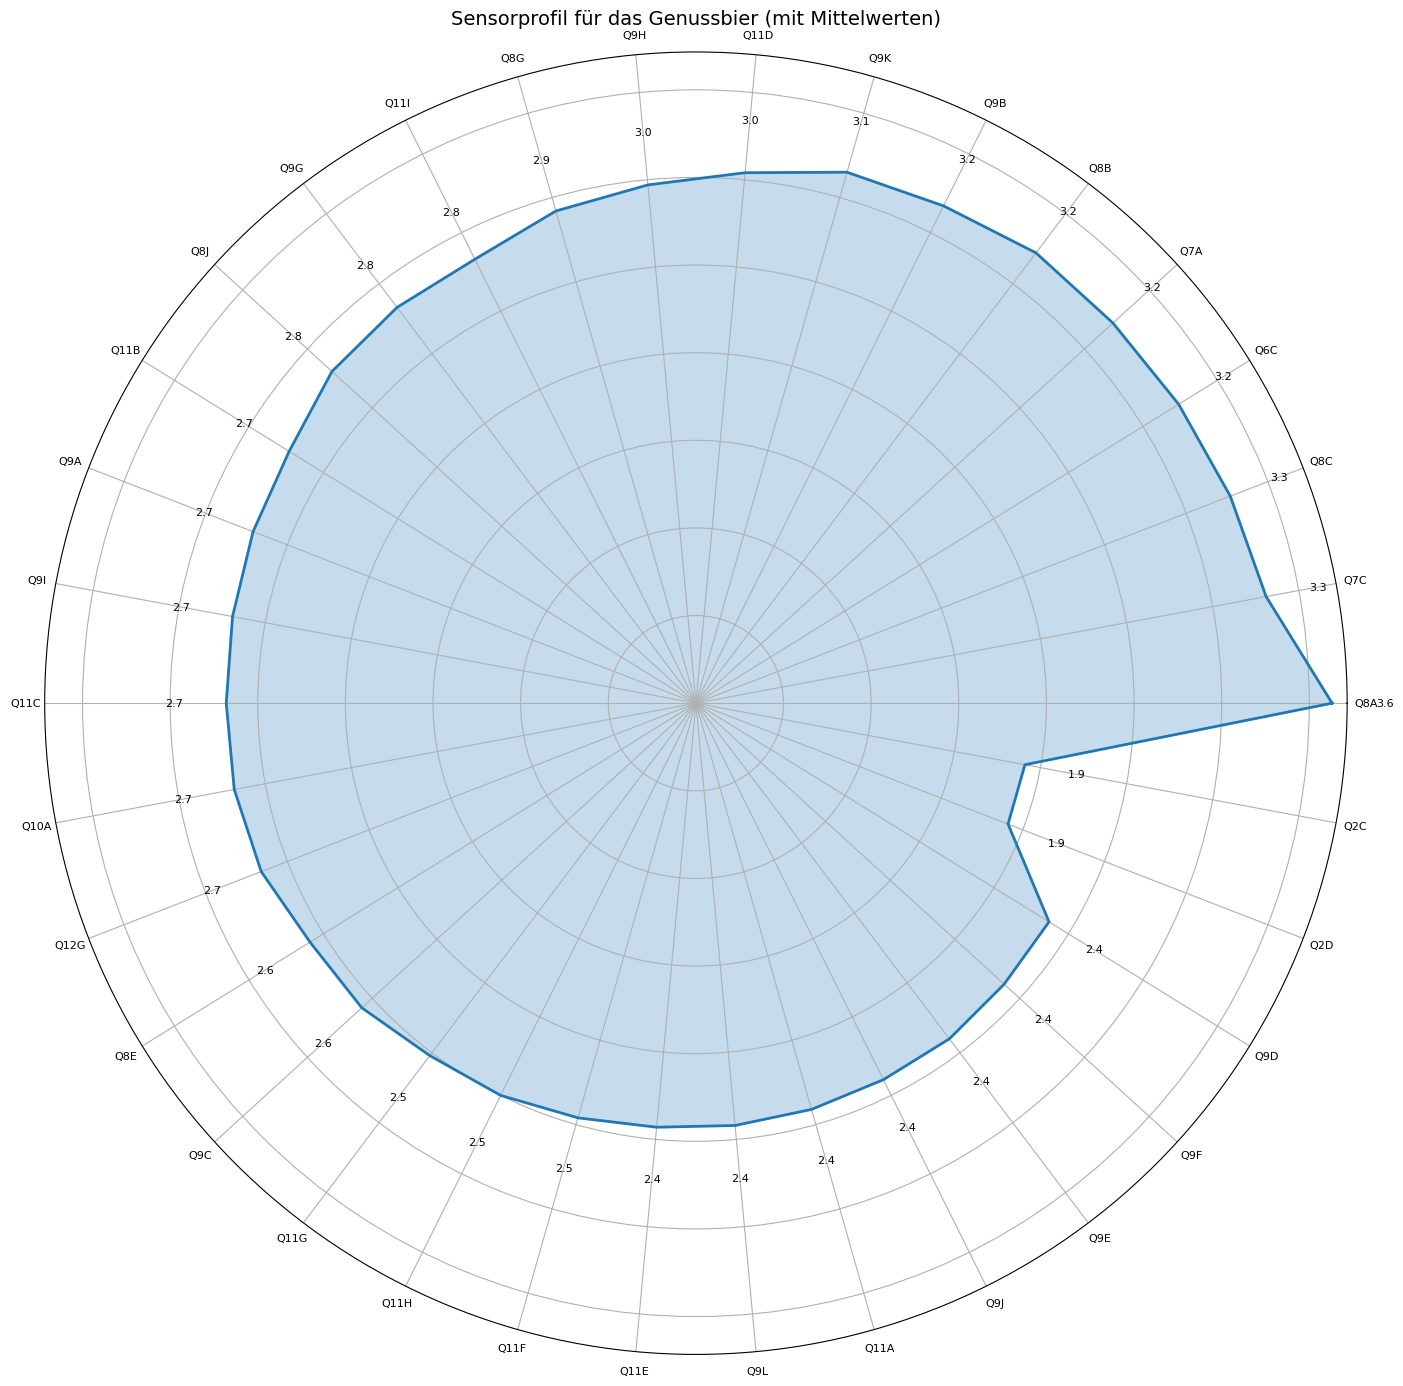

In [56]:
# 6. Radar-Plot erzeugen
fig, ax = plt.subplots(figsize=(14, 14), subplot_kw=dict(polar=True))
ax.plot(angles, values, linewidth=2, color='tab:blue')
ax.fill(angles, values, alpha=0.25, color='tab:blue')

# Achsenticks und -beschriftung
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=8, rotation=90)
ax.set_yticklabels([])

# Werte an den Punkten anzeigen
for i, (angle, value) in enumerate(zip(angles, values)):
    if i < len(labels):  # das letzte ist nur zur Kreis-Schließung
        ax.text(angle, value + 0.3, f"{value:.1f}", ha='center', va='center', fontsize=8, color='black')

# Titel setzen
ax.set_title("Sensorprofil für das Genussbier (mit Mittelwerten)", size=14, pad=20)
plt.savefig("sensorprofil_genussbier.png", dpi=300)
plt.tight_layout()
plt.show()

In [57]:
# 7. Klartext-Fragen für jede Variable
fragen_dict = {
    "Q2C": "zuhause beim Essen",
    "Q2D": "zuhause zur Entspannung",
    "Q6C": "Es macht mir großen Spaß ein Bier oder bierhaltiges Getränk zu konsumieren.",
    "Q7A": "Gesunde Ernährung ist mir sehr wichtig.",
    "Q7C": "Ich probiere sehr gerne neue Produkte oder Geschmacksrichtungen aus.",
    "Q8A": "Geschmack des Getränks",
    "Q8B": "Geruch/Aroma des Getränks",
    "Q8C": "Kaufpreis des Getränks",
    "Q8E": "Nachhaltige Produktion des Getränks",
    "Q8G": "Design der Verpackung",
    "Q8J": "Alkoholgehalt des Getränks",
    "Q9A": "Alkoholfreies Bier oder alkoholfreie Biermischgetränke",
    "Q9B": "Weizenbier/Weißbier/Berliner Weisse",
    "Q9C": "Kölsch",
    "Q9D": "Altbier (bspw. Diebels)",
    "Q9E": "Pale Ale (IPA etc.)",
    "Q9F": "Stout (bspw. Guinness)",
    "Q9G": "Märzen/Export/Kellerbier/Zwickelbier",
    "Q9H": "Radler/Biermischgetränke (bspw. Cola-Bier)",
    "Q9I": "Pils/Pilsner",
    "Q9J": "Bockbier/Schwarzbier/Rauchbier (bspw. Köstritzer)",
    "Q9K": "Helles oder Lager (bspw. Augustiner)",
    "Q9L": "Craft Beer",
    "Q10A": "Alkoholfreies Bier ohne Alkohol (0% Alkoholgehalt)",
    "Q11A": "rauchiger Geschmack",
    "Q11B": "herber-hopfiger Geschmack",
    "Q11C": "süßlich-malziger Geschmack",
    "Q11D": "fruchtiger Geschmack",
    "Q11E": "Geschmack nach Kräutern",
    "Q11F": "Geschmack nach Gewürzen",
    "Q11G": "bitterer Geschmack",
    "Q11H": "säuerlicher Geschmack",
    "Q11I": "Zitrusgeschmack",
    "Q12G": "Verkaufsförderung/Angebote vor Ort im Handel"
}

# 8. Variablen umbenennen und sortiert ausgeben
means_named = means.rename(index=fragen_dict)
means_named_df = means_named.reset_index()
means_named_df.columns = ["Frage", "Durchschnittlicher Wert"]

# 9. Ausgabe als sortierte Tabelle im Terminal
print(means_named_df.to_string(index=False))


                                                                      Frage  Durchschnittlicher Wert
                                                     Geschmack des Getränks                     3.63
       Ich probiere sehr gerne neue Produkte oder Geschmacksrichtungen aus.                     3.31
                                                     Kaufpreis des Getränks                     3.27
Es macht mir großen Spaß ein Bier oder bierhaltiges Getränk zu konsumieren.                     3.24
                                    Gesunde Ernährung ist mir sehr wichtig.                     3.22
                                                  Geruch/Aroma des Getränks                     3.22
                                        Weizenbier/Weißbier/Berliner Weisse                     3.17
                                       Helles oder Lager (bspw. Augustiner)                     3.15
                                                       fruchtiger Geschmack                

In [ ]:
from openai import OpenAI
import time

# 1. OpenAI-Client initialisieren (API-Key hier einfügen)
client = OpenAI(api_key="")

# 2. Prompt mit Skalen und Mittelwerten
genuss_prompt = """
Du bist Biersommelier:in und Spezialist:in für sensorische Konsumentenprofile.

Basierend auf den folgenden Mittelwerten aus einer Umfrage und den zugehörigen Antwortskalen, sollst du ein literarisches, aber fundiertes Sensorprofil eines innovativen „Genussbieres“ formulieren. Der Text soll sich lesen wie die Beschreibung eines sensorisch ausgereiften Produkts auf einem Bieretikett oder in einem Fachkatalog.

Bitte berücksichtige die Mittelwerte UND die Antwortskalen. Höhere Werte bedeuten tendenziell stärkere Zustimmung oder Präferenz. Der Text soll max. 300 Wörter lang sein.

### Mittelwerte & Skalen (repräsentative Auswahl):

Frage,Durchschnittlicher Wert,Antwortskala
Geschmack des Getränks,3.63,['sehr geringer Einfluss(1)', ..., 'sehr starker Einfluss(5)']
Ich probiere sehr gerne neue Produkte oder Geschmacksrichtungen aus.,3.31,['trifft überhaupt nicht zu(1)', ..., 'trifft voll und ganz zu(5)']
Kaufpreis des Getränks,3.27,['sehr geringer Einfluss(1)', ..., 'sehr starker Einfluss(5)']
Es macht mir großen Spaß ein Bier oder bierhaltiges Getränk zu konsumieren.,3.24,['trifft überhaupt nicht zu(1)', ..., 'trifft voll und ganz zu(5)']
Gesunde Ernährung ist mir sehr wichtig.,3.22,['trifft überhaupt nicht zu(1)', ..., 'trifft voll und ganz zu(5)']
Geruch/Aroma des Getränks,3.22,['sehr geringer Einfluss(1)', ..., 'sehr starker Einfluss(5)']
Weizenbier/Weißbier/Berliner Weisse,3.17,['sehr niedrige Präferenz(1)', ..., 'sehr hohe Präferenz(5)']
Helles oder Lager (bspw. Augustiner),3.15,keine Skala vorhanden
fruchtiger Geschmack,3.04,['sehr niedrige Präferenz(1)', ..., 'sehr hohe Präferenz(5)']
Radler/Biermischgetränke (bspw. Cola-Bier),2.97,['sehr niedrige Präferenz(1)', ..., 'sehr hohe Präferenz(5)']
Design der Verpackung,2.92,['sehr geringer Einfluss(1)', ..., 'sehr starker Einfluss(5)']
Zitrusgeschmack,2.83,['sehr niedrige Präferenz(1)', ..., 'sehr hohe Präferenz(5)']
Märzen/Export/Kellerbier/Zwickelbier,2.83,['sehr niedrige Präferenz(1)', ..., 'sehr hohe Präferenz(5)']
Alkoholgehalt des Getränks,2.81,['sehr geringer Einfluss(1)', ..., 'sehr starker Einfluss(5)']
herber-hopfiger Geschmack,2.73,['sehr niedrige Präferenz(1)', ..., 'sehr hohe Präferenz(5)']
Alkoholfreies Bier oder alkoholfreie Biermischgetränke,2.71,['sehr niedrige Präferenz(1)', ..., 'sehr hohe Präferenz(5)']
Pils/Pilsner,2.69,['sehr niedrige Präferenz(1)', ..., 'sehr hohe Präferenz(5)']
süßlich-malziger Geschmack,2.68,['sehr niedrige Präferenz(1)', ..., 'sehr hohe Präferenz(5)']
Alkoholfreies Bier ohne Alkohol (0% Alkoholgehalt),2.68,['sehr niedrige Präferenz(1)', ..., 'sehr hohe Präferenz(5)']
Verkaufsförderung/Angebote vor Ort im Handel,2.66,['gar nicht(1)', ..., 'sehr stark(5)']
Nachhaltige Produktion des Getränks,2.59,['sehr geringer Einfluss(1)', ..., 'sehr starker Einfluss(5)']
Kölsch,2.58,['sehr niedrige Präferenz(1)', ..., 'sehr hohe Präferenz(5)']
bitterer Geschmack,2.52,['sehr niedrige Präferenz(1)', ..., 'sehr hohe Präferenz(5)']
säuerlicher Geschmack,2.5,['sehr niedrige Präferenz(1)', ..., 'sehr hohe Präferenz(5)']
Geschmack nach Gewürzen,2.46,['sehr niedrige Präferenz(1)', ..., 'sehr hohe Präferenz(5)']
Geschmack nach Kräutern,2.43,['sehr niedrige Präferenz(1)', ..., 'sehr hohe Präferenz(5)']
Craft Beer,2.42,['sehr niedrige Präferenz(1)', ..., 'sehr hohe Präferenz(5)']
rauchiger Geschmack,2.41,['sehr niedrige Präferenz(1)', ..., 'sehr hohe Präferenz(5)']
Bockbier/Schwarzbier/Rauchbier (bspw. Köstritzer),2.4,['sehr niedrige Präferenz(1)', ..., 'sehr hohe Präferenz(5)']
Pale Ale (IPA etc.),2.4,['sehr niedrige Präferenz(1)', ..., 'sehr hohe Präferenz(5)']
Stout (bspw. Guinness),2.38,['sehr niedrige Präferenz(1)', ..., 'sehr hohe Präferenz(5)']
Altbier (bspw. Diebels),2.37,['sehr niedrige Präferenz(1)', ..., 'sehr hohe Präferenz(5)']
zuhause zur Entspannung,1.91,['nie(1)', 'gelegentlich(2)', 'häufig(3)']
zuhause beim Essen,1.91,['nie(1)', 'gelegentlich(2)', 'häufig(3)']

### Aufgabe:

Formuliere basierend auf den obigen Daten ein vollständiges sensorisches Textprofil des idealen Genussbieres. Kombiniere Werte sinnvoll (z. B. Geschmack + Fruchtigkeit + Aroma), aber erwähne keine Mittelwerte oder Skalen – nur das Ergebnis in Worten.
"""

# 3. Assistant erstellen
assistant = client.beta.assistants.create(
    name="GenussBierProfiler",
    instructions=(
        "Du bist ein erfahrener Biersommelier, spezialisiert auf die sensorische Beschreibung "
        "von neuen Biersorten. Dein Ziel ist es, aus Konsumenten-Umfragedaten ein professionelles "
        "Sensorprofil zu formulieren, das für Marketing, Etikettendesign und Innovationsentwicklung geeignet ist."
    ),
    model="gpt-4o"
)

# 4. Thread starten
thread = client.beta.threads.create()

# 5. Nachricht an den Thread senden
client.beta.threads.messages.create(
    thread_id=thread.id,
    role="user",
    content=genuss_prompt
)

# 6. Assistant starten
run = client.beta.threads.runs.create(
    thread_id=thread.id,
    assistant_id=assistant.id
)

# 7. Auf Fertigstellung warten
while True:
    run_status = client.beta.threads.runs.retrieve(thread_id=thread.id, run_id=run.id)
    if run_status.status == "completed":
        break
    elif run_status.status == "failed":
        raise Exception("Fehlgeschlagen.")
    time.sleep(1)

# 8. Ausgabe anzeigen
messages = client.beta.threads.messages.list(thread_id=thread.id)
for message in messages.data:
    if message.role == "assistant":
        print("\n🟢 Sensorprofil Genussbier:\n")
        print(message.content[0].text.value)


/var/folders/vb/3fgx1mm954q9j0shqmng75q00000gn/T/ipykernel_5236/2983145451.py:70: DeprecationWarning: The Assistants API is deprecated in favor of the Responses API
  thread = client.beta.threads.create()
/var/folders/vb/3fgx1mm954q9j0shqmng75q00000gn/T/ipykernel_5236/2983145451.py:73: DeprecationWarning: The Assistants API is deprecated in favor of the Responses API
  client.beta.threads.messages.create(
/var/folders/vb/3fgx1mm954q9j0shqmng75q00000gn/T/ipykernel_5236/2983145451.py:80: DeprecationWarning: The Assistants API is deprecated in favor of the Responses API
  run = client.beta.threads.runs.create(
/var/folders/vb/3fgx1mm954q9j0shqmng75q00000gn/T/ipykernel_5236/2983145451.py:87: DeprecationWarning: The Assistants API is deprecated in favor of the Responses API
  run_status = client.beta.threads.runs.retrieve(thread_id=thread.id, run_id=run.id)
/var/folders/vb/3fgx1mm954q9j0shqmng75q00000gn/T/ipykernel_5236/2983145451.py:95: DeprecationWarning: The Assistants API is deprecated 


🟢 Sensorprofil Genussbier:

Tauchen Sie ein in das exquisite Erlebnis unseres innovativen Genussbieres – eine Symbiose aus Tradition und Avantgarde, das sich durch seine ausbalancierte Komplexität und zugängliche Eleganz auszeichnet.

Unser Bier entfaltet einen wohlabgestimmten, aromatischen Charakter, der von einem dezenten fruchtigen Bouquet geprägt ist. Diese fruchtigen Nuancen verweben sich harmonisch mit einem subtilen Hauch von Zitrus, der im Einklang mit der leichten Weizensüße steht. Der Geschmack ist reichhaltig und dennoch erfrischend, was das Glas zu einem ständigen Begleiter auf der Reise durch neue sensorische Horizonte macht.

Ein solides Gerüstaroma nimmt Sie auf eine olfaktorische Entdeckungsreise mit. Dabei wird der angenehme Duft von Malz durch zarte, florale Spuren begleitet. Für die Liebhaber von milderen Sinneseindrücken ist unser Bier eine Einladung in eine Welt, in der jeder Schluck Behaglichkeit und Freude schenkt. Während herbe Hopfennoten und ein bitterer Unt